# Generate 2D Dataset with Missing Values under MAR

Mathematically, missing at random (MAR) means:

$$P(M = 1|X^{obs}, X^{miss}) = P(M =1|X^{obs})$$

Translated to code, this means:<br>
Missingness depends only on observed variables, which means that, for each sample missingness is generated by a function of some of or all of observed variable data in this sample.                    

#### Example 1: Missing values exist only at one variable

We plan to generate a 2-dimensional dataset with missing values under MAR assumption. In the first example, let's keep one variable as the "determining feature", which means this variable is always observed. Let's say our X1 represents *Age*, which is the determining feature, and X2 represents *Income*, which miss values with overall missing rate $R$.

The logic of generate synthetic data with missing values under MAR is:
- Firstly, generate a complete dataset
- Secondly, determine the missing probability model based on the missing logic. <br>
For example, the missing logic here is the older people are less likely to reveal their income.
- Third, generate incomplete dataset based on missing probability.

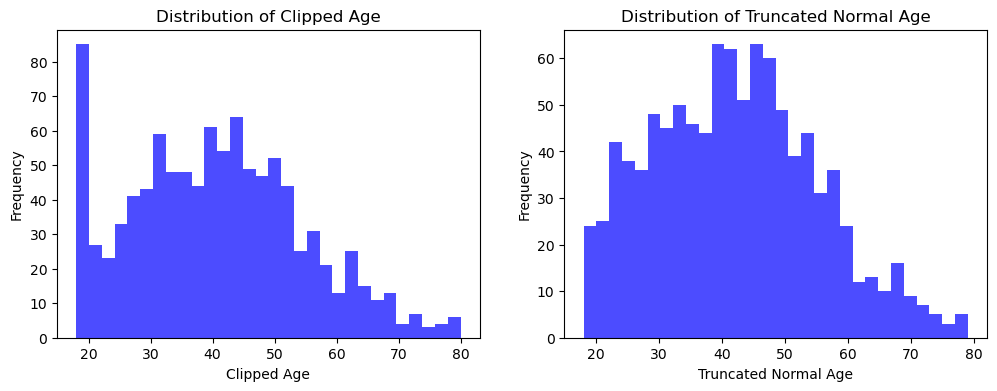

COMPLETE DATASET (before introducing missingness)
   age        income
0   29  48561.863844
1   26  39517.653916
2   46  71587.617656
3   49  89306.756690
4   21  18672.412955
5   63  82125.391187
6   22  45198.008067
7   43  74470.101147
8   49  72397.949424
9   57  64320.460024

Missing values:0


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.stats import truncnorm

# Set seed for reproducibility
np.random.seed(42)

#######################################################
# Step 1: Generate Complete Dataset (No Missing Values)
#######################################################

n = 1000        # number of observations

# Generate Age (this will always be observed)
age = np.random.normal(loc=40, scale=15, size=n)
age_clipped = np.clip(age, 18, 80)

def generate_truncated_normal(n=1000, mean=40, std=15, low=18, high=80):
    a = (low - mean) / std
    b = (high - mean) / std
    age = truncnorm.rvs(a, b, loc=mean, scale=std, size=n)
    return np.round(age).astype(int)

age_truncated = generate_truncated_normal(1000)

# Simple visualization of age generated in different way
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(age_clipped, bins=30, alpha=0.7, color='blue')
ax[0].set_title("Distribution of Clipped Age")
ax[0].set_xlabel("Clipped Age")
ax[0].set_ylabel("Frequency")

ax[1].hist(age_truncated, bins=30, alpha=0.7, color='blue')
ax[1].set_title("Distribution of Truncated Normal Age")
ax[1].set_xlabel("Truncated Normal Age")
ax[1].set_ylabel("Frequency")
plt.show()

age = age_truncated

# Generate Income
income = 30000 + 800 * age + np.random.normal(0, 15000, n)
income = np.maximum(income, 0)

# Create complete dataset (Using age_truncated)
df_complete = pd.DataFrame({'age': age, 'income': income})
print("="*70)
print("COMPLETE DATASET (before introducing missingness)")
print("="*70)
print(df_complete.head(10))
print(f"\nMissing values:{df_complete.isnull().sum().sum()}")


MISSINGNESS PROBABILITIES
Age range:18.0 to 79.0
Probability range: 0.132 to 0.946
Mean probability: 0.497


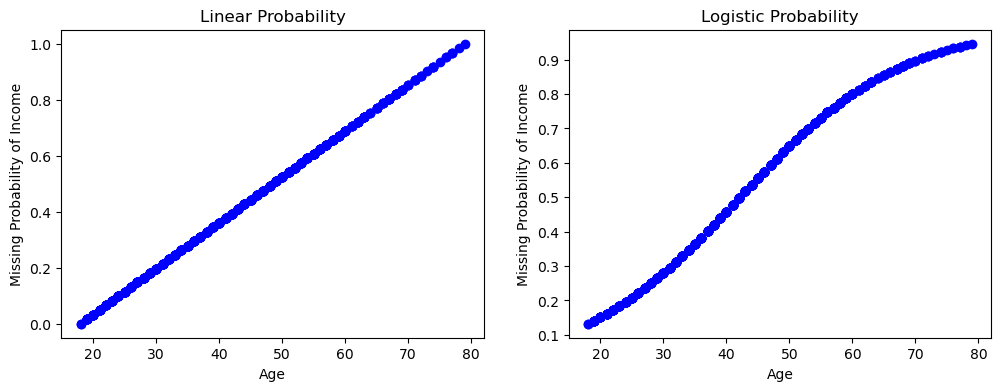

In [26]:
#########################################################################
# Step 2: Define Missingness Probability Based on Observed Variable (Age)
#########################################################################

# MAR Mechanism: Let's say older people are more likely to have missing income

# Method 1: Linear relationship (then convert to probability)

# Normalize age to [0,1]
age_normalized = (age - age.min()) / (age.max() - age.min())

# Create base probability: younger -> higher missing probability
base_prob = age_normalized   # **2

# Method 2: Logistic function (more flexible and common)
# P(missing | age) = logistic( beta0 + beta1 * age_standardized)
age_standardized = (age - age.mean())/age.std()

# Define coefficients for logistic regression
beta0 = 0
beta1 = 1

# Calculate probability using logistic function
prob_missing_logistic = expit(beta0 + beta1 * age_standardized)


# Visualize missing probability model
print("\n" + "="*70)
print("MISSINGNESS PROBABILITIES")
print("="*70)
print(f"Age range:{age.min():.1f} to {age.max():.1f}")
print(f"Probability range: {prob_missing_logistic.min():.3f} to {prob_missing_logistic.max():.3f}")
print(f"Mean probability: {prob_missing_logistic.mean():.3f}")

fig, ax = plt.subplots(1, 2, figsize = (12,4))
ax[0].scatter(age, base_prob, color='blue')
ax[0].set_title("Linear Probability")
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Missing Probability of Income")

ax[1].scatter(age, prob_missing_logistic, color='blue')
ax[1].set_title("Logistic Probability")
ax[1].set_xlabel("Age")
ax[1].set_ylabel("Missing Probability of Income")
plt.show()

- Adjust probability to align the overall missing rate

We have an desired overall missing rate of the dataset $R$, and for each *income*, the missing probability denote as $P_i$. Let $P_{adj,i} denote the adjusted missing probability for each *income*. Then according to the definition of the overall missing rate, we have:

$$ \frac{1}{n} \sum_{i=1}^N P_{adj,i} = R,$$

which means after adjusting, the average missing probability of all *income* should be equal to the overall missing rate.

$$ R = \frac{\bar{P}}{\bar{P}} R = \frac{\frac{1}{n}\sum_{i=1}^N P_i}{\bar{P}} R = \frac{1}{n}\sum_{i=1}^{n} (P_i \frac{R}{\bar{P}})$$

So, we have:

$$P_{adj,i} = P_i \frac{R}{\bar{P}}$$

That's how we adjust the missing probabilities of each *income*.

In [27]:
############################################################
# Step 3: Adjust to Achieve Desired Overall Missingness Rate
############################################################

desired_missingness_rate = 0.3

# Scale probabilities to achieve desired rate
scaling_factor = desired_missingness_rate / prob_missing_logistic.mean()
prob_missing_adjusted = prob_missing_logistic * scaling_factor

# Clip to valid probability range [0,1]
prob_missing_adjusted = np.clip(prob_missing_adjusted, 0, 1)

print(f"\nAfter adjustment:")
print(f"Mean probability: {prob_missing_adjusted.mean():.3f}")


After adjustment:
Mean probability: 0.300


In [28]:
#####################################
# Step 4: Generate Missing Indicators
#####################################

# Method 1: 
# For each observation, we generate a random number.
# If random number < probability, that observation becomes missing

random_draws = np.random.random(n)
is_missing = random_draws < prob_missing_adjusted

print(f"\nNumber of missing values generated (by random draw): {is_missing.sum()}({is_missing.mean():.1%})")

# Method 2:
# Using binomial distribution generate 1 or 0 in a certain probability
random_indicator = np.random.binomial(1, prob_missing_adjusted).astype(bool)

print(f"\nNumber of missing values generated (by binomial draw): {random_indicator.sum()}({random_indicator.mean():.1%})")



Number of missing values generated (by random draw): 307(30.7%)

Number of missing values generated (by binomial draw): 300(30.0%)


In [29]:
####################################################
# Step 5: Applying Missingness to Create MAR Dataset
####################################################

df_mar = df_complete.copy()
df_mar.loc[random_indicator, "income"] = np.nan

print("\n" + "="*70)
print("MAR DATASET (after introducing missingness)")
print("="*70)
print(df_mar.head(10))
print(f"\nMissing income values: {df_mar['income'].isnull().sum()}({df_mar['income'].isnull().mean():.1%})")


MAR DATASET (after introducing missingness)
   age        income
0   29  48561.863844
1   26  39517.653916
2   46  71587.617656
3   49  89306.756690
4   21  18672.412955
5   63  82125.391187
6   22  45198.008067
7   43  74470.101147
8   49  72397.949424
9   57           NaN

Missing income values: 300(30.0%)


In [30]:
#############################
# step 6: Verify MAR Property
#############################

print("\n"+ "="*70)
print("VERFICATION OF MAR PROPERTY")
print("="*70)

# Check 1: Missingness should correlate with Age
print("\nCheck 1: Does missingness depend on Age (observed variable)?")
print(f"Mean age when income is observed: {df_mar[df_mar['income'].notna()]['age'].mean():.1f}")
print(f"Mean age when income is missing: {df_mar[df_mar['income'].isna()]['age'].mean():.1f}")
print("-> If MAR is correct, there should be DIFFERENT (younger -> more missing)")

# Check 2: Among people of similar age, missingness should NOT depend on income
print("\nCheck 2: Among people of similar age, does missingness depend on income?")
age_group = (age >= 35) & (age <= 45)       # People aged 35-45
income_in_group = df_complete.loc[age_group, 'income']
missing_in_group = is_missing[age_group]

print(f"For age 35-45:")
print(f"Mean income when observed:{income_in_group[~missing_in_group].mean():.0f}")
print(f"Mean income when missing (from complete data): {income_in_group[missing_in_group].mean():.0f}")
print("-> If MAR is correct, there should be SIMILAR (missing doesn't depend on income)")


VERFICATION OF MAR PROPERTY

Check 1: Does missingness depend on Age (observed variable)?
Mean age when income is observed: 40.2
Mean age when income is missing: 46.7
-> If MAR is correct, there should be DIFFERENT (younger -> more missing)

Check 2: Among people of similar age, does missingness depend on income?
For age 35-45:
Mean income when observed:62568
Mean income when missing (from complete data): 61739
-> If MAR is correct, there should be SIMILAR (missing doesn't depend on income)


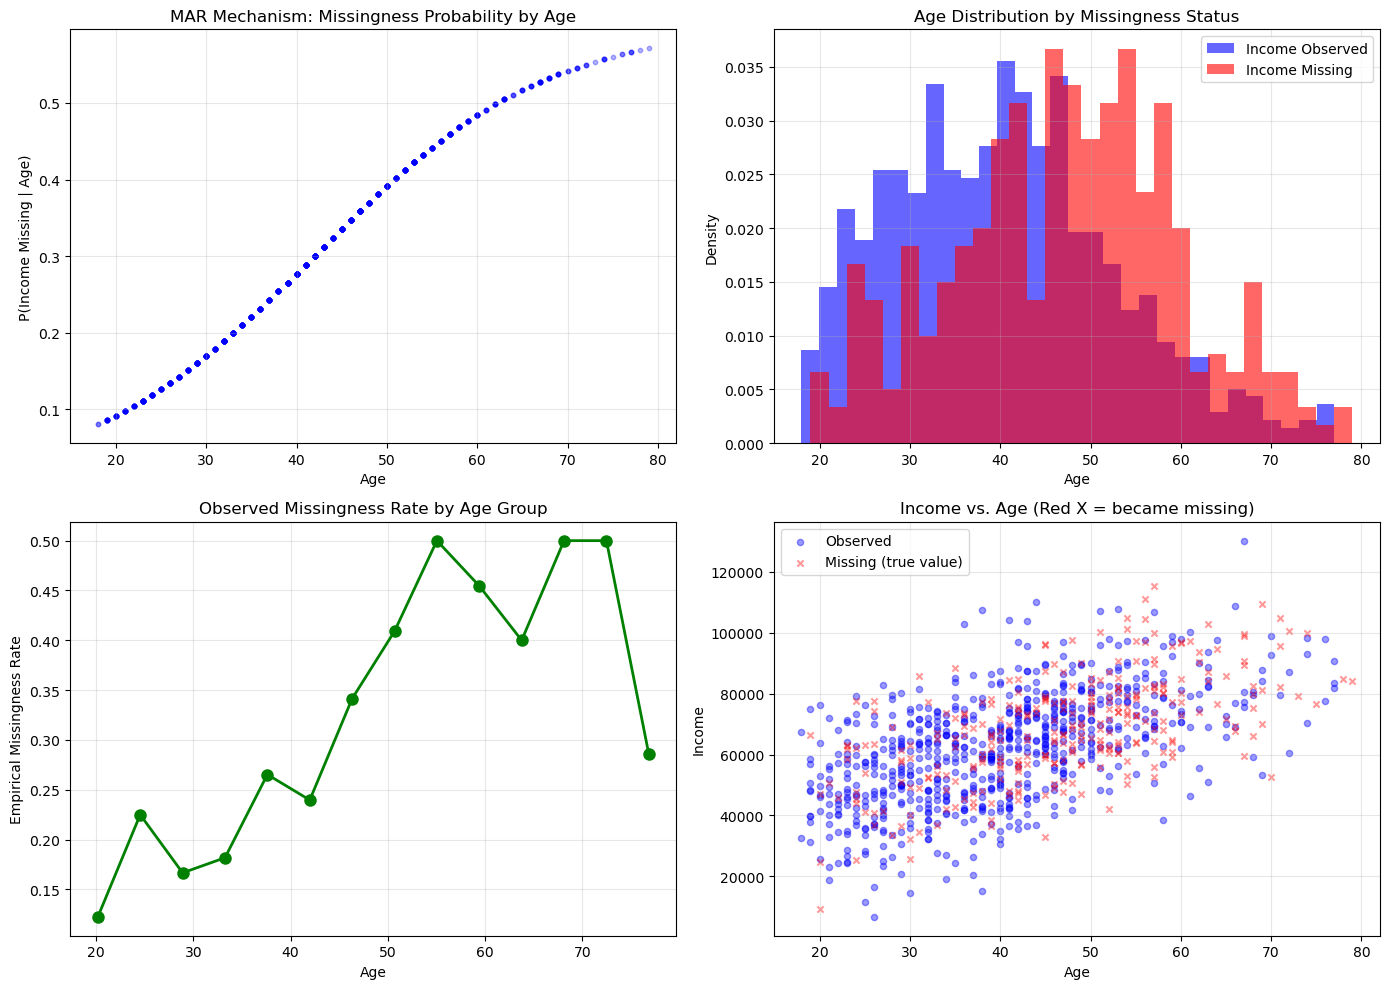

In [31]:
# =============
# VISUALIZATION
# =============

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Missingness probability vs. Age
axes[0,0].scatter(age, prob_missing_adjusted, alpha=0.3, s=10, color='blue')
axes[0,0].set_xlabel("Age")
axes[0,0].set_ylabel('P(Income Missing | Age)')
axes[0,0].set_title("MAR Mechanism: Missingness Probability by Age")
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Age distribution by missingness status
axes[0,1].hist(df_mar[df_mar['income'].notna()]['age'], bins=30, alpha=0.6, label='Income Observed', density=True, color='blue')
axes[0,1].hist(df_mar[df_mar['income'].isna()]['age'], bins=30, alpha=0.6, label='Income Missing', density=True, color='red')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Density')
axes[0,1].set_title('Age Distribution by Missingness Status')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Empirical missingness rate by age bins
age_bins = np.linspace(age.min(), age.max(), 15)
empirical_miss_rate = []
bin_centers = []

for i in range(len(age_bins) -1):
    mask = ((df_mar['age'] >= age_bins[i]) & (df_mar['age'] < age_bins[i+1]))
    if mask.sum() > 0:
        empirical_miss_rate.append(df_mar[mask]['income'].isnull().mean())
        bin_centers.append((age_bins[i] + age_bins[i+1])/2)

axes[1,0].plot(bin_centers, empirical_miss_rate, 'o-', linewidth=2, markersize=8, color='green')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Empirical Missingness Rate')
axes[1,0].set_title('Observed Missingness Rate by Age Group')
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Income vs. Age (showing which are missing)
observed_mask = df_mar['income'].notna()
axes[1,1].scatter(df_mar.loc[observed_mask, 'age'], df_mar.loc[observed_mask, 'income'], alpha=0.4, s=20, label='Observed', color='blue')
axes[1,1].scatter(df_complete.loc[~observed_mask, 'age'], df_complete.loc[~observed_mask, 'income'], alpha=0.4, s=20, label='Missing (true value)', color='red', marker='x')
axes[1,1].set_xlabel('Age')
axes[1,1].set_ylabel('Income')
axes[1,1].set_title('Income vs. Age (Red X = became missing)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#### Example 2: Missing values exist in both variable

In this case, we don't have a determining feature, but we still need to generate missingness according to MAR definition. Let's say the missingness logic is that the older people are less likely to reveal their income, and people with lower income are less likely to reveal their age. To ensure MAR setting, we can split the data by row into two group, and repeat the above logic on two variable as determining feature respectively in different groups:

- Firstly, split the complete dataset randomly into two groups.
- Secondly, in the first group, keep *Age* as the determining feature, implement the above process.
- Third, in the second group, keep *Income* as the determining feature, implement the above process based on new added missingness logic.
- Finally combine the two groups.

                 Age              Income  Sample Size
Group1  42.02(12.70)  64270.05(18271.45)          500
Group2  42.25(13.00)  63586.23(17768.66)          500


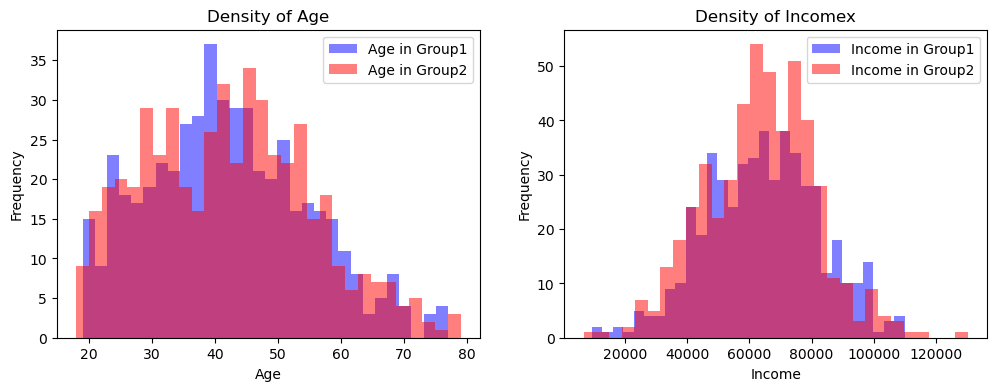

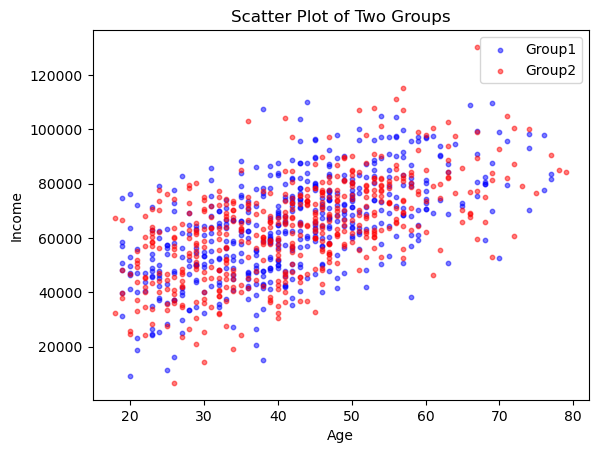

In [32]:
from sklearn.model_selection import train_test_split

# ===========================================
# Step 1: Randomly split the complete dataset
# ===========================================

group1_complete, group2_complete = train_test_split(df_complete, test_size=0.5, random_state=312,shuffle=True)

# Compare this two dataset
stats_groups = pd.DataFrame({'Age': [f"{group1_complete['age'].mean():.2f}({group1_complete['age'].std():.2f})", 
                                     f"{group2_complete['age'].mean():.2f}({group2_complete['age'].std():.2f})"],
                             'Income':[f"{group1_complete['income'].mean():.2f}({group1_complete['income'].std():.2f})", 
                                       f"{group2_complete['income'].mean():.2f}({group2_complete['income'].std():.2f})"],
                             'Sample Size':[group1_complete.shape[0], group2_complete.shape[0]]
                                       },
                            index=['Group1', 'Group2'])

print(stats_groups)


# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(group1_complete['age'], bins=30, color='blue', label="Age in Group1", alpha=0.5)
ax[0].hist(group2_complete['age'], bins=30, color='red', label="Age in Group2", alpha=0.5)
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Density of Age")
ax[0].legend()

ax[1].hist(group1_complete['income'], bins=30, color='blue', label="Income in Group1", alpha=0.5)
ax[1].hist(group2_complete['income'], bins=30, color='red', label="Income in Group2", alpha=0.5)
ax[1].set_xlabel("Income")
ax[1].set_ylabel("Frequency")
ax[1].set_title("Density of Incomex")
ax[1].legend()
plt.show()

plt.scatter(group1_complete['age'], group1_complete['income'], color='blue', s=10, alpha=0.5, label='Group1')
plt.scatter(group2_complete['age'], group2_complete['income'], color='red', s=10, alpha=0.5, label='Group2')
plt.xlabel('Age')
plt.ylabel('Income')
plt.title("Scatter Plot of Two Groups")
plt.legend()
plt.show()

Since we are going to process the same steps on different variables, a tool that is used to process the above steps would be every convenient. We decide to design a class to achieve that goal, because object-oriented programming is better choice for further expanding. In a bigger vision, this tool should be able to generate synthetic data with missing values under any three missingness mechanism.

But here, for coherence purpose, we only build a small part of this tool class `MAR`. The goal of class `MAR` is that, given a 2-dimensional complete dataset $X$, `MAR` outputs the corresponding incomplete dataset.

In [33]:
class MAR:
    def __init__(self,
                 dataset,
                 target_vars,
                 deter_vars,
                 model,
                 missing_rate,
                 seed=None):
        '''
        Generate Missing At Random (MAR) missingness mechanism.

        Parameters
        ----------
        dataset: pd.Dataframe
            complete dataset which determines the shape of final output.
        target_vars: pd.Series or pd.DataFrame
            Variable to introduce missingness into. (e.g., df['X1] or df['X1','X2])
        deter_vars: pd.Series or pd.DataFrame
            Determining features that are fully observed columns driving missingness
        model: callable
            Function to compute P(missing at target_vars | deter_vars) = f(deter_vars)
            Should accept standardized deter_vars and return probabilities
        missing_rate: float
            Desired proportion of missing values.
        seed: int, optional
            Random seed for reproducibility.
        '''
        # Validate missing_rate
        if not 0 <= missing_rate <= 1:
            raise ValueError(f"missing_rate must be in [0,1], got {missing_rate}")
        
        # Convert to numpy arrays and validate shapes
        self.target_vars, self.target_names = self._validate_and_convert(target_vars, "target_vars")
        self.deter_vars, self.deter_names = self._validate_and_convert(deter_vars, "deter_vars")

        # Ensure same number of samples
        if len(self.target_vars) != len(self.deter_vars):
            raise ValueError(
                f"target_vars and deter_vars must have same number of samples."
                f"Got {len(self.target_vars)} and {len(self.deter_vars)}"
            )
        
        self.dataset = dataset.copy()
        self.model = model
        self.missing_rate = missing_rate
        self.seed = seed
        self.missing_prob_adjusted = None   # will be computed in generate_mask
        self.n_samples = len(self.target_vars)

        # Set random seed if provided
        if seed is not None:
            np.random.seed(seed)

    def _validate_and_convert(self, data, name):
        '''Convert input to numpy array and validate.'''

        names = []

        if isinstance(data, pd.Series):
            names = [data.name if data.name is not None else 'col_0']
            data = data.values
        elif isinstance(data, pd.DataFrame):
            names = data.colums.tolist()
            data = data.values
        elif isinstance(data, np.ndarray):
            # If it's a raw array, we generate generic names
            values = data
            if values.ndim == 1:
                names = ['col_0']
            else:
                names = [f"col_{i}" for i in range(values.shape[1])]
        else:
            raise TypeError(
                f"{name} must be numpy array, pandas Series, or Dataframe"
            )
        # Ensure 2D
        if data.ndim == 1:
            data = data.reshape(-1, 1)
        elif data.ndim > 2:
            raise ValueError(f"{name} must be 1D or 2D, got {data.ndim}D")
        
        return data, names
    

    def generate_mask(self, return_prob=False):
        '''
        Generate mask and missingness probability for each observation in target_vars.
        
        return_prob: bool, default=False
            If True, also return the missing probabilities 
        
        Returns
        -------
        self.mask: np.array
            Boolean mask indicating missing positions (True = missing)
        self.missing_prob_adjusted: np.ndarray
            Probability of missingness for each sample adjusted by missing rate, shape(n_samples,) (only if return_prob=True)
        '''
        # Handle case where deter_vars has zero variance
        deter_vars_std = self.deter_vars.std(axis=0)
        deter_vars_mean = self.deter_vars.mean(axis=0)

        # Avoid division by zero
        deter_vars_std[deter_vars_std == 0] =1.0

        # Normalize deter_vars: (X - mean) / std
        deter_vars_norm = (self.deter_vars - deter_vars_mean) / deter_vars_std

        # Generate missing probability according to model
        # Model should return shape (n_samples,)
        missing_prob = self.model(deter_vars_norm)

        # Validate model output
        if missing_prob.ndim > 1:
            if missing_prob.shape[1] == 1:
                missing_prob = missing_prob.ravel()
            else:
                raise ValueError(
                    f"model must return 1D array, got shape {missing_prob.shape}"
                )
            
        if len(missing_prob) != self.n_samples:
            raise ValueError(
                f"model output length {len(missing_prob)} doesn't match number of samples {self.n_samples}"
            )

        # Adjust probabilities to align with overall missing_rate
        # Handle edge case where all probabilities in [0,1]
        if missing_prob.mean() == 0:
            # If model produces all zeros, use uniform probabilities
            missing_prob = np.ones(self.n_samples) / self.n_samples

        self.missing_prob_adjusted = missing_prob * (self.missing_rate / missing_prob.mean())

        # Clip to valid probability range [0,1]
        self.missing_prob_adjusted = np.clip(self.missing_prob_adjusted, 0, 1)

        # Warn if we couldn't achieve exact missing rate
        achievable_rate = self.missing_prob_adjusted.mean()
        if abs(achievable_rate - self.missing_rate) > 0.05:
            import warnings
            warnings.warn(
                f"Could not achieve exact missing_rate={self.missing_rate:.3f}."
                f"Achievable rate is {achievable_rate:.3f}."
                f"Consider using a different model function."
            )
        
        # Convert missing probabilities into boolean mask (True = missing)
        self.mask = np.random.binomial(1, self.missing_prob_adjusted, size=self.n_samples).astype(bool)

        if return_prob:
            return self.mask, self.missing_prob_adjusted
        else:
            return self.mask

    def apply(self):
        '''
        Apply missingness to target variables and output dataset under MAR assumption.
        
        Returns
        -------
        X_missing: np.ndarray
            Target variables with missing values (NaN), same shapes as target_vars
        
        '''
        # Generate probabilities
        mask = self.generate_mask(return_prob=False)

        # Apply mask to target_vars in the dataset
        self.dataset.loc[mask, self.target_names] = np.nan

        return self.dataset
        
    def get_statistics(self):
        '''
        Get statistics about the missingness mechanism.

        Returns
        -------
        stats: dict
            Dictionary containing:
            - n_samples: number of samples
            - missing_rate_target: target missing rate
            - missing_rate_achievable: achievable missing rate after clipping
            - prob_min: minimum missing probability
            - prob_max: maximum missing probability
            - prob_mean: mean missing probability
        '''
        if self.missing_prob_adjusted is None:
            self.generate_mask()

        return {
            'n_samples': self.n_samples,
            'n_target_vars': self.target_vars.shape[1],
            'n_deter_vars': self.deter_vars.shape[1],
            'missing_rate_target': self.missing_rate,
            'missing_rate_achievable': self.missing_prob_adjusted.mean(),
            'prob_min': self.missing_prob_adjusted.min(),
            'prob_max': self.missing_prob_adjusted.max(),
            'prob_mean': self.missing_prob_adjusted.mean(),
            'prob_std': self.missing_prob_adjusted.std(),
        }
        

In [34]:
# ========================================
# Apply on complete data group1 and group2
# ========================================

# Define probability model for income, the logic is older people are less likely to reveal their income.
# P(missing | age) = logistic( beta0 + beta1 * age_standardized)
def model_income(age_standardized, beta0=0, beta1=1):
    return expit(beta0 + beta1 * age_standardized.ravel())

# Define probability model for age, the logic is people earn less are less likely to reveal their age.
# P(missing | income) = logistic( beta0 + beta1 * income_standardized)
def model_age(income_standardized, beta0=0, beta1=-1):
    return expit(beta0 + beta1 * income_standardized.ravel())

# ==============================
# For group1, we mask the income
# ==============================
# Create two MAR instance for group1
mar_income = MAR(dataset=group1_complete,
                 target_vars=group1_complete['income'],
                 deter_vars=group1_complete['age'],
                 model=model_income,
                 missing_rate=0.60,
                 seed=42)

# Apply missingness
group1_missing = mar_income.apply()

# Get statistics
missingstats_income = mar_income.get_statistics()

# ===========================
# For group2, we mask the age
# ===========================
# Create two MAR instance for group2
mar_age = MAR(dataset=group2_complete,
              target_vars=group2_complete['age'],
              deter_vars=group2_complete['income'],
              model=model_age,
              missing_rate=0.60,
              seed=42)

# Apply missingness
group2_missing = mar_age.apply()

# Get statistics
missingstats_age = mar_age.get_statistics()

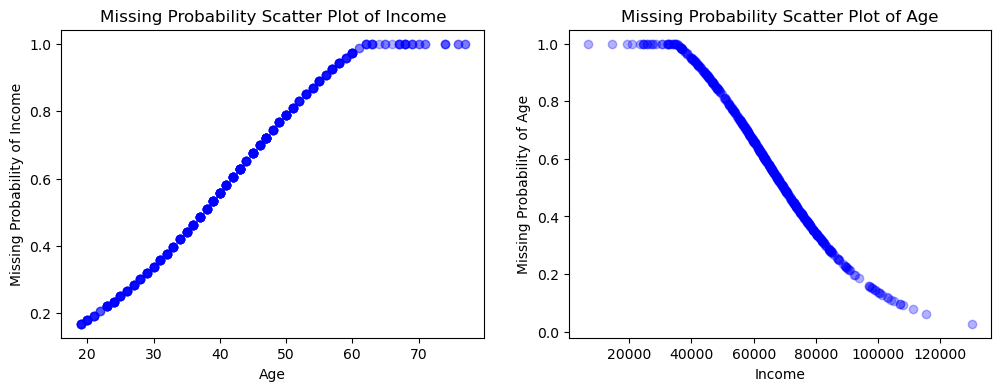



Statistics for income:
n_samples: 500
n_target_vars: 1
n_deter_vars: 1
missing_rate_target: 0.6
missing_rate_achievable: 0.5953818175013117
prob_min: 0.1692407330091719
prob_max: 1.0
prob_mean: 0.5953818175013117
prob_std: 0.24622503992368494

Statistics for age:
n_samples: 500
n_target_vars: 1
n_deter_vars: 1
missing_rate_target: 0.6
missing_rate_achievable: 0.5970043368067348
prob_min: 0.02746706689066366
prob_max: 1.0
prob_mean: 0.5970043368067348
prob_std: 0.24275868636616288


In [35]:
# =============
# Visualization
# =============

# Adjusted probabilities:
mask_income, missing_prob_income = mar_income.generate_mask(return_prob=True)
mask_age, missing_prob_age = mar_age.generate_mask(return_prob=True)

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].scatter(group1_complete['age'], missing_prob_income, alpha=0.3, color='blue')
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Missing Probability of Income")
ax[0].set_title("Missing Probability Scatter Plot of Income")

ax[1].scatter(group2_complete['income'], missing_prob_age, alpha=0.3, color='blue')
ax[1].set_xlabel("Income")
ax[1].set_ylabel("Missing Probability of Age")
ax[1].set_title("Missing Probability Scatter Plot of Age")
plt.show()

print("\n" + "="*70)
print("\nStatistics for income:")
for key, value in missingstats_income.items():
    print(f"{key}: {value}")
    
print("\nStatistics for age:")
for key, value in missingstats_age.items():
    print(f"{key}: {value}")

In [36]:
# Combine this two group back to one dataset
df_mar = pd.concat([group1_missing, group2_missing], axis=0).sort_index()

print(f"The final empirical missing_rate is: {df_mar.isna().sum().sum() / (df_mar.shape[0]*df_mar.shape[1])}")

print("\n"+ "="*70)
print("VERFICATION OF MAR PROPERTY")
print("="*70)

# Check: Missingness should correlate with the observed variable
print("\nCheck 1: Does missingness in Income depend on Age (observed variable)?")
print(f"Mean age when income is observed: {df_mar[df_mar['income'].notna()]['age'].mean():.1f}")
print(f"Mean age when income is missing: {df_mar[df_mar['income'].isna()]['age'].mean():.1f}")
print("-> If MAR is correct, there should be DIFFERENT (younger -> more missing)")

print("\nCheck 1: Does missingness in Age depend on Income (observed variable)?")
print(f"Mean income when age is observed: {df_mar[df_mar['age'].notna()]['income'].mean():.1f}")
print(f"Mean income when age is missing: {df_mar[df_mar['age'].isna()]['income'].mean():.1f}")
print("-> If MAR is correct, there should be DIFFERENT (earn more -> more missing)")


The final empirical missing_rate is: 0.2935

VERFICATION OF MAR PROPERTY

Check 1: Does missingness in Income depend on Age (observed variable)?
Mean age when income is observed: 40.7
Mean age when income is missing: 47.7
-> If MAR is correct, there should be DIFFERENT (younger -> more missing)

Check 1: Does missingness in Age depend on Income (observed variable)?
Mean income when age is observed: 65711.1
Mean income when age is missing: 56732.1
-> If MAR is correct, there should be DIFFERENT (earn more -> more missing)
